<a href="https://colab.research.google.com/github/Sam-Arkle/CS5455/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The assignment**
Submit two ipynb files. One for linear regression. One for logistic regression.

z = x dot w

for linear regression: y = z, p(t|x) = Gaussian(y, sigma^2)

for logistic regression: y = 1/(1+exp(-z)), p(t|x) = Bernoulli(y)

For both regression:

    Define distribution of error
    Define the model y = ...
    Derive the cost function, J
    Solve for dJ/dy
    Solve for dy/dz
    Solve for dz/dw
    Solve for the gradient
    Solve for the hessian matrix

Test solution with simulated data

    generated random true w
    generate random x in range (-1, 1)
    compute y from x and true w using the model
    generate random t according to the error distribution p(t|x)
    perform gradient descent starting with a random w with small enough learning rate, alpha
    show that the optimized w is close to the true w
    perform newton-raphson method (gradient and hessian) and show the same.


**Linear regression**

*Sources*
[Wiki](https://en.wikipedia.org/wiki/Linear_regression)

[IBM](https://www.ibm.com/topics/linear-regression#:~:text=register%20for%20TechXchange-,What%20is%20linear%20regression%3F,is%20called%20the%20independent%20variable.)

[Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf)


Linear regression is a supervised machine learning algorithm, that learns from the labelled datasets and maps the data points to the most optimized linear functions that can be used for prediction on new datasets.

We want to cover:

1.   What are the probabalistic underpinnings for this model.
2.   How these underpinings derive a cost function.
3.   Importance of the derivative and gradient
4.   Showing a basic implementation.


**The probabalistic underpinnings**


Linear regression is a model that estimates the linear relationship between a scalar response (dependent variable) and one or more explanatory variables (regressor or independent variable).

If there is one explanatory variable we denote the model simple linear regression. More than one: multiple linear regression. This is distinct from multivariate linear regression, where multiple correlated dependent variables are predicted, rather tha a single scalar variable.

Linear regression focuses on the conditional probability distribution of the response given the values of the predictors, rather than on the joint probability distribution of all of these variables (that being the domain of multivariate analysis).

[Bishop] The simplest linear model for regression is one that involves a linear combination of the input variables:


$\mathbf{y} = \mathbf{z} =  \mathbf{x} \cdot \mathbf{w}$

Where $\mathbf{x} = (\mathcal{x}_1,...\mathcal{x}_n)$ is a vector of input variables (aka features or predictors).

 And $\mathbf{w}$ is a vector of weights (coefficients) that we multiply with the input variables. We choose our values of $\mathbf{w}$ to minimize our error function with the ultimate aim of making the best possible predictions on new data.

 We don't assume a probabalistic ditribution on $\mathbf{x}$ but we do assume a distribution on our errors.

The conditional probability:

$p(\mathbf{t} | \mathbf{x}) $

expresses our uncertainty about the value of some target value $t$ for a given value of $x$. [Bishop] "From this conditional distribution we can make predictions of $t$, for any new value of $x$ in such a way as to minimize the expected value of a suitably chosen loss function".

We assume that the target variable is a linear combination of the input features and some normally distributed noise, and so the conditional probability (for a given target variable) is assumed to be:

$p(t_i | \mathbf{x}) = \mathcal{N}(y, σ^2) $

We want to maximize this value (have a high probability that we have made a correct prediction).

To derive a cost function (which will measure how well our model fits our data) we maximize this value for all our target data, that is we want to maximize the likelihood function:

$p(\mathbf{t}, \mathbf{X}) = ∏_i p(t_i|\mathbf{x})$

(Note: We can simply multiply the probabilites together as we assume the datapoints are drawn independently).

To make our costs function easier to work with we take the natural logarithm of the likelihood function:

$\ln{p(\mathbf{t}, \mathbf{X})} = \ln{∏_i p(t_i|\mathbf{x})}$

$=\sum^{i=N}_{i=1} \ln{p(t_i|\mathbf{x})} $

$=\sum^{i=N}_{i=1} \ln{\mathcal{N}(y, σ^2)}$

As a reminder: $\mathcal{N}(x|μ, σ^2) = \frac{1}{(2Πσ^2)^{\frac{1}{2}}}e^{-\frac{1}{2σ^2}(x - μ)^2}$

So our previous sum is directly proportional to:

$∑^{i=N}_{i=1} (y(\mathbf{x}_i) - t_i)^2$

Which is our cost function $J$.

Solving for $\frac{dJ}{dy}$ we get:

$\frac{dJ}{dy} = 2(y-t)$

As $y = z$ solving for $\frac{dy}{dz}$ we get:

$\frac{dy}{dz} = 1$

Solving for $\frac{dz}{dw}$ we get:

$\frac{dz}{dw} = \mathbf{x}$

As we want to minimize the cost function we find the gradient:

$\frac{dJ}{dw_i} = 2(y-t) x_i$

And we want to find the hessian:

$\frac{d_2J}{dw_iw_j} = 2 x_i x_j + 0 * (y-t)$

$= 2x_ix_j$




Weights found through gradient descent:  [-0.33014681 -1.59342668]
Actual weights:  [-0.31885351 -1.60298056]


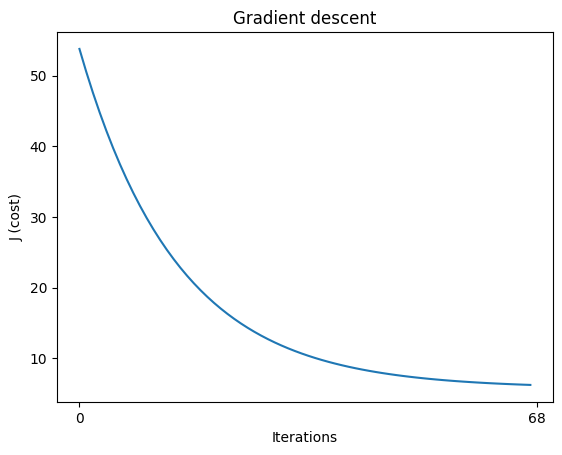

In [16]:
# Now we can test our solution with simulated data

import numpy as np
import matplotlib.pyplot as plt

#1. generated random true w -- We want a 'true' weight vector. To keep this simple we can use just two weights
np.random.seed(33)

rt_w = np.random.randn(2)


# 2. generate random x in range (-1, 1)
x = np.random.uniform(-1, 1, (1000,2)) # A random array, 1000 rows and 2 columns, normally distributed

# 3. compute y from x and true w using the model
y = x.dot(rt_w)

# 4. generate random t according to the error distribution p(t|x)
sigma = 0.2
t = y + np.random.normal(0, sigma, y.shape)

# 5. perform gradient descent starting with a random w with small enough learning rate, alpha
# Gradient descent allows us to find the value that minimizes our cost function.

w = np.random.randn(2) # We create two new random weights as initial values
alpha = 0.1
j_array = [] # This array will be used to display the gradient descent graphically.
iterations = 0
# Calculating the gradient descent
while abs(rt_w[1] - w[1]) > 0.01:
  y_pred = x.dot(w)
  gradient = (1/len(x)) * 2 * x.T.dot(y_pred - t)  # The inclusion of 1 / N is to average the gradient over all samples
  w -= alpha * gradient

  J = np.sum(2 * (y_pred - t))
  j_array.append(J)
  iterations +=1
# 6. show that the optimized w is close to the true w
print("Weights found through gradient descent: ", w)
print("Actual weights: ", rt_w)
# print("Our y-intercept is", w[0])  # This will only be true once we've implemented our column of 1's

plt.plot(range(iterations), j_array)
plt.title("Gradient descent")
plt.xlabel("Iterations")
plt.ylabel("J (cost)")
plt.xticks([0, iterations])
# plt.yticks([])

plt.show()

# Question to ask later: This works for most seed values but not all, something evidently wrong. Determine what.



Weights found through Newton-Raphson [-0.3237173  -1.60664622]
Actual weights:  [-0.31885351 -1.60298056]


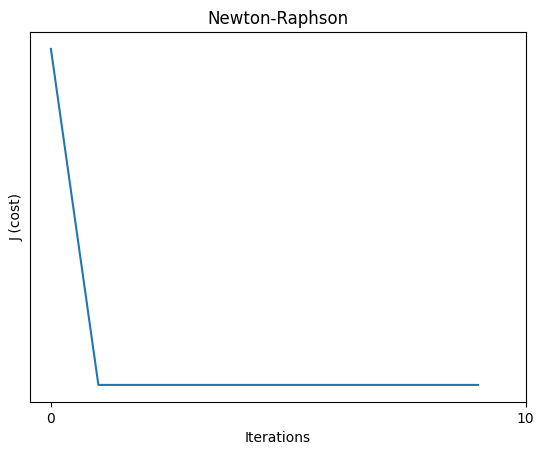

In [13]:
#7. perform newton-raphson method (gradient and hessian) and show the same.
w2 = np.random.randn(2) # We choose two new initial weights

j_array2 = []
iterations = 10
# while abs(rt_w[1] - w2[1]) > 0.01:
for _ in range(iterations):
  y_pred = x.dot(w2)
  gradient =   2 * x.T.dot(y_pred - t)
  hessian =    2 * x.T.dot(x)
  w2 -= np.linalg.inv(hessian).dot(gradient)

  J = np.sum(2 * (y_pred - t))
  j_array2.append(J)


print("Weights found through Newton-Raphson", w2)
print("Actual weights: ", rt_w)

plt.plot(range(iterations), j_array2)
plt.title("Newton-Raphson")
plt.xlabel("Iterations")
plt.ylabel("J (cost)")
plt.xticks([0, iterations])
plt.yticks([])

plt.show()
